# CodeAlpha Internship — Task 3: Data Visualization

## Geldium Delinquency Dataset

Transform the customer data into clear charts that reveal patterns and support decision-making.

## Questions
1. What is the delinquency rate?
2. How is credit utilization distributed?
3. How does DTI differ by delinquency?
4. Which employment groups have higher observed delinquency?
5. Which card types and locations have higher observed rates?
6. What relationships appear between income, loan balance, credit score and utilization?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_excel("Delinquency_prediction_dataset.xlsx")
for c in ["Income","Loan_Balance","Credit_Score"]: df[c]=df[c].fillna(df[c].median())
df["Employment_Status"]=df["Employment_Status"].astype(str).str.strip().replace({"EMP":"Employed","employed":"Employed","retired":"Retired"})
print(df.shape)
df.head()


(500, 19)


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,Employed,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


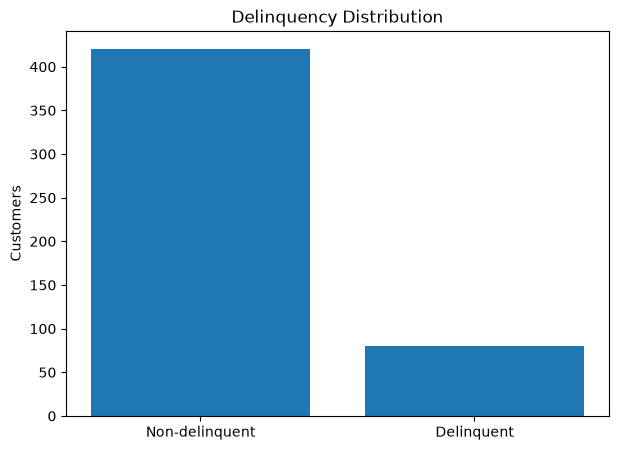

In [2]:
# 1. Delinquency distribution
x=df["Delinquent_Account"].value_counts().sort_index()
plt.figure(figsize=(7,5)); plt.bar(["Non-delinquent","Delinquent"],x.values)
plt.title("Delinquency Distribution"); plt.ylabel("Customers"); plt.show()


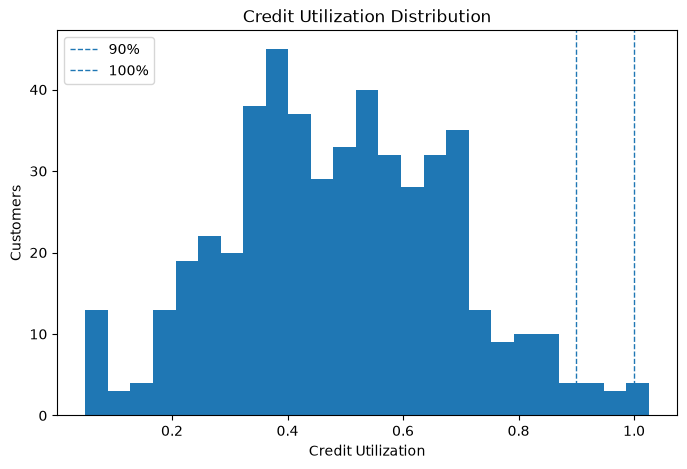

In [3]:
# 2. Credit utilization
plt.figure(figsize=(8,5)); plt.hist(df["Credit_Utilization"],bins=25)
plt.axvline(.90,linestyle="--",linewidth=1,label="90%"); plt.axvline(1.0,linestyle="--",linewidth=1,label="100%")
plt.title("Credit Utilization Distribution"); plt.xlabel("Credit Utilization"); plt.ylabel("Customers"); plt.legend(); plt.show()


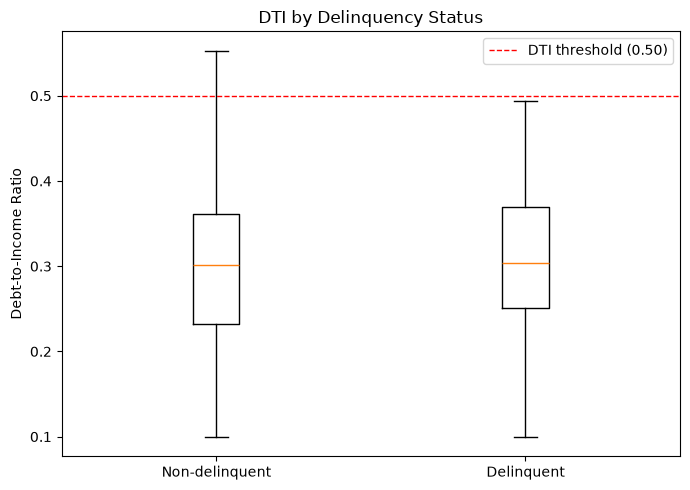

In [10]:
# 3. DTI
non_delinquent_dti = df.loc[df["Delinquent_Account"] == 0, "Debt_to_Income_Ratio"].dropna()
delinquent_dti = df.loc[df["Delinquent_Account"] == 1, "Debt_to_Income_Ratio"].dropna()

groups = [non_delinquent_dti, delinquent_dti]

plt.figure(figsize=(7, 5))
plt.boxplot(
    groups,
    tick_labels=["Non-delinquent", "Delinquent"]
)
plt.axhline(0.50, linestyle="--", linewidth=1, color="red", label="DTI threshold (0.50)")
plt.title("DTI by Delinquency Status")
plt.ylabel("Debt-to-Income Ratio")
plt.legend()
plt.tight_layout()
plt.show()

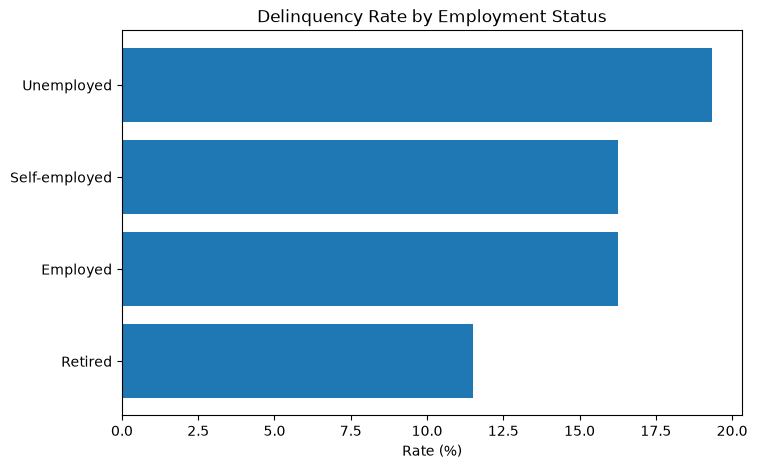

In [5]:
# 4. Employment
r=df.groupby("Employment_Status").Delinquent_Account.mean().sort_values()*100
plt.figure(figsize=(8,5)); plt.barh(r.index,r.values); plt.title("Delinquency Rate by Employment Status"); plt.xlabel("Rate (%)"); plt.show()


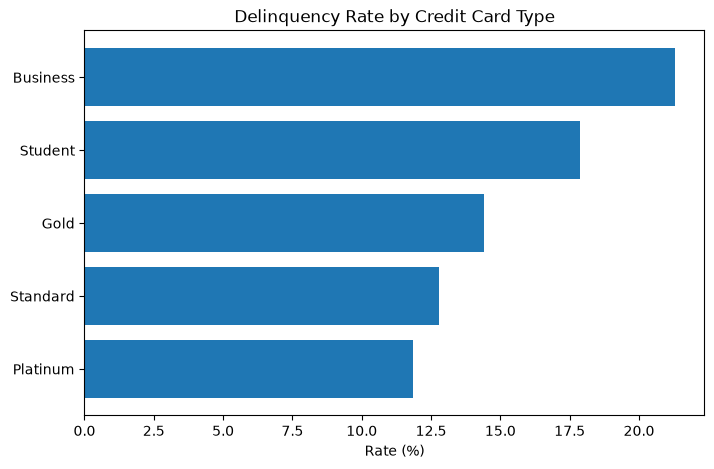

In [6]:
# 5. Card type
r=df.groupby("Credit_Card_Type").Delinquent_Account.mean().sort_values()*100
plt.figure(figsize=(8,5)); plt.barh(r.index,r.values); plt.title("Delinquency Rate by Credit Card Type"); plt.xlabel("Rate (%)"); plt.show()


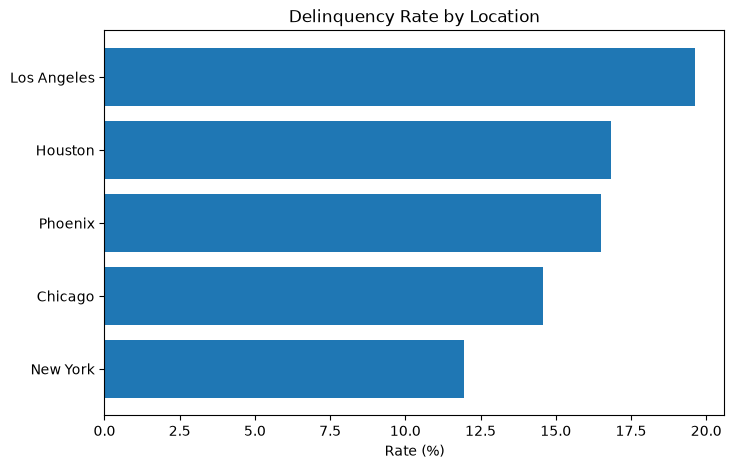

In [7]:
# 6. Location
r=df.groupby("Location").Delinquent_Account.mean().sort_values()*100
plt.figure(figsize=(8,5)); plt.barh(r.index,r.values); plt.title("Delinquency Rate by Location"); plt.xlabel("Rate (%)"); plt.show()


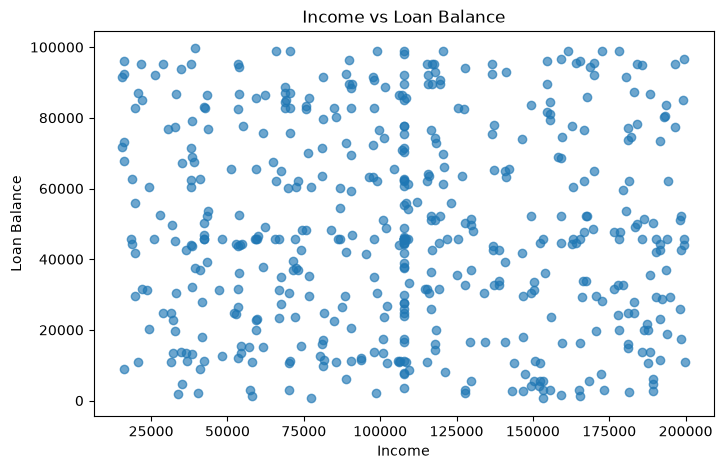

In [8]:
# 7. Income vs loan balance
plt.figure(figsize=(8,5)); plt.scatter(df.Income,df.Loan_Balance,alpha=.65)
plt.title("Income vs Loan Balance"); plt.xlabel("Income"); plt.ylabel("Loan Balance"); plt.show()


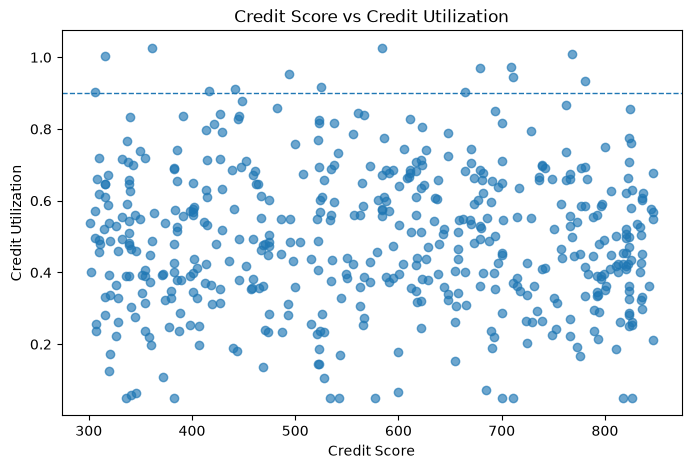

In [9]:
# 8. Credit score vs utilization
plt.figure(figsize=(8,5)); plt.scatter(df.Credit_Score,df.Credit_Utilization,alpha=.65); plt.axhline(.90,linestyle="--",linewidth=1)
plt.title("Credit Score vs Credit Utilization"); plt.xlabel("Credit Score"); plt.ylabel("Credit Utilization"); plt.show()


## Final Data Story

- 16% of customers are delinquent.
- Credit utilization and DTI are useful financial indicators to monitor.
- Employment, card type and location show different observed delinquency rates.
- These are associations, not proof of causation.
- Counterintuitive payment-history and credit-score patterns found in EDA should be validated before operational use.